<a href="https://colab.research.google.com/github/carormex/Proyecto_final_TM/blob/main/Problema1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Mining & Image Recognition — Proyecto Final

### Ingrid Carolina Ortíz Mejicanos
## Problema 1: Word Cloud

**Objetivo:** identificar los 3 usuarios más populares en un dataset de aprox 800,000 tweets, construir un corpus por usuario y determinar la razón por la que se les cita.


## 0. Instalación y configuración



In [ ]:
!pip -q install wordcloud spacy nltk gdown
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import spacy
from nltk.stem import SnowballStemmer
from wordcloud import WordCloud

pd.set_option("display.max_colwidth", 120)

# ---------------- Parámetros ----------------
DATASET_URL = "https://drive.google.com/file/d/1zIo_BgbuuoN_gCU_kpimZ4PMX8t0C0hI/view"  # tw_source.csv.zip
ZIP_PATH    = "/content/tw_source.csv.zip"   # archivo descargado
DATA_DIR    = "/content/tw_data"             # carpeta de extracción
TOP_N       = 3                       # # de usuarios
WINDOW      = 7                       # palabras seleccionadas
TOP_WORDS   = 10                      # palabras en cada wordcloud
SPACY_MODEL = "en_core_web_sm"        # usar "es_core_news_sm" si los tweets están en español
STEM_LANG   = "english"               # "spanish" si los tweets están en español

## 1. Carga del dataset

La función de carga detecta si el archivo trae encabezado o si sigue el formato *Sentiment140* (sin encabezado, codificación `latin-1`, columnas `target, ids, date, flag, user, text`) y normaliza los nombres a: `id`, `timestamp`, `user`, `text`.

In [ ]:
import os, glob, zipfile, gdown

if not os.path.exists(ZIP_PATH):
    gdown.download(DATASET_URL, ZIP_PATH, quiet=False, fuzzy=True)

with zipfile.ZipFile(ZIP_PATH) as z:
    print("Contenido del zip:", z.namelist())
    z.extractall(DATA_DIR)

csv_files = [f for f in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True) if "__MACOSX" not in f]
DATA_PATH = max(csv_files, key=os.path.getsize)   # se toma el CSV de mayor tamaño
print("Archivo a cargar:", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1zIo_BgbuuoN_gCU_kpimZ4PMX8t0C0hI
From (redirected): https://drive.google.com/uc?id=1zIo_BgbuuoN_gCU_kpimZ4PMX8t0C0hI&confirm=t&uuid=f5098d97-95ff-445d-802f-65771b03c18f
To: /content/tw_source.csv.zip
100%|██████████| 85.1M/85.1M [00:02<00:00, 41.4MB/s]


Contenido del zip: ['tw_source.csv', '__MACOSX/._tw_source.csv']
Archivo a cargar: /content/tw_data/tw_source.csv


In [ ]:
SENT140_COLS = ["target", "ids", "date", "flag", "user", "text"]

def read_any_encoding(path, **kwargs):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False, **kwargs)
        except UnicodeDecodeError:
            continue
    raise ValueError("No fue posible decodificar el archivo.")

def load_tweets(path):
    """Carga el CSV y normaliza los nombres de columnas a: id, timestamp, user, text."""
    raw = read_any_encoding(path, header=None)
    if raw.shape[1] == 6 and str(raw.iloc[0, 0]).strip() in {"0", "2", "4"}:
        raw.columns = SENT140_COLS                                   # Sentiment140 sin encabezado
    else:
        raw = read_any_encoding(path)                                # el archivo trae encabezado
        raw.columns = [str(c).strip().lower() for c in raw.columns]

    rename = {"ids": "id", "tweet_id": "id", "tweetid": "id", "status_id": "id",
              "date": "timestamp", "created_at": "timestamp", "datetime": "timestamp", "time": "timestamp",
              "content": "text", "tweet": "text", "tweet_text": "text", "message": "text",
              "username": "user", "screen_name": "user", "user_name": "user"}
    raw = raw.rename(columns=rename)
    raw = raw.loc[:, ~raw.columns.duplicated()]

    # Respaldo: si no hay columna de texto, se toma la columna de texto con mayor longitud promedio
    if "text" not in raw.columns:
        obj_cols = raw.select_dtypes("object").columns
        raw = raw.rename(columns={max(obj_cols, key=lambda c: raw[c].astype(str).str.len().mean()): "text"})
    if "id" not in raw.columns:
        raw["id"] = raw.index
    if "timestamp" not in raw.columns:
        raw["timestamp"] = None
    return raw

df = load_tweets(DATA_PATH)
print(f"Registros: {len(df):,}")
print("Columnas:", list(df.columns))
df.head()

Registros: 1,600,000
Columnas: ['target', 'id', 'timestamp', 'flag', 'user', 'text']


,target,id,timestamp,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


## 2. Usuarios más populares (expresiones regulares)

Se considera **popular** al usuario con mayor número de menciones (`@usuario`) dentro de los tweets.
Patrón utilizado: `@` seguido de 1 a 15 caracteres alfanuméricos o guion bajo. Se normaliza a minúsculas para no separar `@User` de `@user`.

In [ ]:
MENTION_RE = re.compile(r"(?<![\w@])@([A-Za-z0-9_]{1,15})")

df["mentions"] = df["text"].astype(str).str.findall(MENTION_RE)
df["mentions"] = df["mentions"].apply(lambda ms: [m.lower() for m in ms])

mention_counts = Counter(m for ms in df["mentions"] for m in ms)
top_users = [u for u, _ in mention_counts.most_common(TOP_N)]

ranking = pd.DataFrame(mention_counts.most_common(15), columns=["usuario", "menciones"])
print("Top", TOP_N, "usuarios:", top_users)
ranking

Top 3 usuarios: ['mileycyrus', 'tommcfly', 'ddlovato']


,usuario,menciones
0,mileycyrus,4577
1,tommcfly,3901
2,ddlovato,3473
3,jonasbrothers,2381
4,davidarchie,1385
5,donniewahlberg,1329
6,jonathanrknight,1264
7,jordanknight,1148
8,mitchelmusso,1102
9,taylorswift13,1026


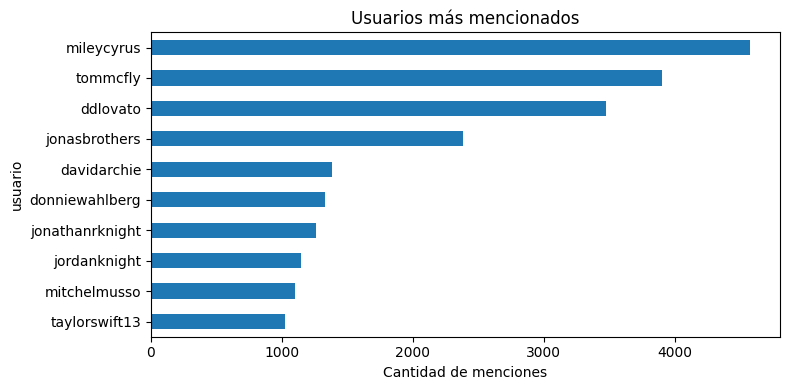

In [ ]:
ax = ranking.head(10).iloc[::-1].plot.barh(x="usuario", y="menciones", legend=False, figsize=(8, 4))
ax.set_title("Usuarios más mencionados")
ax.set_xlabel("Cantidad de menciones")
plt.tight_layout(); plt.show()

## 3. Construcción del corpus por usuario

Cada corpus muestra los tweets que mencionan al usuario seleccionado. Cada documento se estructura como:

- **Content:** texto del tweet.
- **Metadata:** `ID`, `Timestamp` y `Length`

In [ ]:
def build_corpus(data, user):
    """Devuelve una lista de documentos {content, metadata} para el usuario indicado."""
    subset = data[data["mentions"].apply(lambda ms: user in ms)]
    corpus = []
    for _, row in subset.iterrows():
        text = str(row["text"])
        corpus.append({
            "content": text,
            "metadata": {
                "id": row["id"],
                "timestamp": row["timestamp"],
                "length": len(text),          # valor calculado
            },
        })
    return corpus

corpora = {user: build_corpus(df, user) for user in top_users}

for user, corpus in corpora.items():
    print(f"@{user}: {len(corpus):,} documentos")

@mileycyrus: 4,560 documentos
@tommcfly: 3,895 documentos
@ddlovato: 3,459 documentos


In [ ]:
def corpus_to_frame(corpus):
    return pd.DataFrame({
        "content":   [d["content"] for d in corpus],
        "id":        [d["metadata"]["id"] for d in corpus],
        "timestamp": [d["metadata"]["timestamp"] for d in corpus],
        "length":    [d["metadata"]["length"] for d in corpus],
    })

frames = {user: corpus_to_frame(c) for user, c in corpora.items()}

for user, frame in frames.items():
    print(f"\n=== Corpus @{user} ===")
    display(frame.head(5))
    print("Longitud promedio:", round(frame["length"].mean(), 1), "| máxima:", frame["length"].max())


=== Corpus @mileycyrus ===


,content,id,timestamp,length
0,@mileycyrus hahaha dont be like that one time in NY when you got 30 mins of sleep then got sick love you!!,1468063101,Mon Apr 06 23:30:57 PDT 2009,107
1,"@mileycyrus i have the same problem, but it's 4:43 here... let's see if counting works..1234...56 57 58... 132 133 1...",1468286517,Tue Apr 07 00:45:20 PDT 2009,137
2,@mileycyrus I guess counting sheep didn't work Hope you get some sleep!,1468297110,Tue Apr 07 00:49:07 PDT 2009,72
3,@mileycyrus I would too if it meant spending a day in heaven w/my mom and getting to see her again.,1468298918,Tue Apr 07 00:49:44 PDT 2009,100
4,@mileycyrus AWWW u seriously have the cutest dog Miley! Sorry your not with her now Hope u get some sleep! xoxo,1468318249,Tue Apr 07 00:56:41 PDT 2009,112


Longitud promedio: 85.2 | máxima: 156

=== Corpus @tommcfly ===


,content,id,timestamp,length
0,@tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line i was very upset ='( lol..a m...,1468210813,Tue Apr 07 00:19:09 PDT 2009,138
1,@tommcfly Good morning Tom! Why can't I send you a message? This is too short for the question I have Well to bad f...,1468233211,Tue Apr 07 00:26:52 PDT 2009,131
2,@tommcfly did you know that johnsons baby use animals like cute bunnies to test their products?,1468391638,Tue Apr 07 01:23:07 PDT 2009,96
3,"@dougiemcfly @tommcfly good morning guys, how are you all? You know, it's frustrating, I never get a reply",1468502040,Tue Apr 07 02:03:41 PDT 2009,108
4,"@tommcfly hey, no chance of adding brighton or eastbourne to the UCAP tour? gutted im missing out this time round i...",1468618787,Tue Apr 07 02:46:02 PDT 2009,131


Longitud promedio: 86.6 | máxima: 201

=== Corpus @ddlovato ===


,content,id,timestamp,length
0,@ddlovato @David_Henrie ummmmm i cant find it.,1467929230,Mon Apr 06 22:51:34 PDT 2009,47
1,@ddlovato Do you hate us?? Please don't,1467953367,Mon Apr 06 22:58:30 PDT 2009,40
2,@ddlovato Wish that i could see it.. Thats the downside of living in Sweden.. Good Luck anyway,1469661950,Tue Apr 07 07:02:58 PDT 2009,96
3,"@ddlovato hey demi, wen are you and selena gonna do another video? i miss them",1469674492,Tue Apr 07 07:05:11 PDT 2009,79
4,@ddlovato ahhhh i wish i could go to the dallas show...but i wont be near there then,1548280868,Fri Apr 17 20:31:31 PDT 2009,85


Longitud promedio: 87.6 | máxima: 154


## 4. Extracción del contexto

Para cada tweet se toman las palabras anteriores y posteriores a la mención del usuario (window) En esta etapa se eliminan las URLs y las demás menciones.

In [ ]:
URL_RE   = re.compile(r"https?://\S+|www\.\S+")
TOKEN_RE = re.compile(r"@?[a-záéíóúüñ0-9_']+")

def extract_context(text, user, window=WINDOW):
    # Palabras que rodean a la mención @user dentro de un tweet
    text = URL_RE.sub(" ", str(text).lower())
    tokens = TOKEN_RE.findall(text)
    context = []
    for i, tok in enumerate(tokens):
        if tok == "@" + user:
            left  = tokens[max(0, i - window):i]     if window else tokens[:i]
            right = tokens[i + 1:i + 1 + window]     if window else tokens[i + 1:]
            context += left + right
    # se descartan otras menciones y tokens numéricos
    return " ".join(t for t in context if not t.startswith("@") and not t.isdigit())

corpus_contexto = {}
for user, frame in frames.items():
    frame["context"] = frame["content"].apply(lambda t: extract_context(t, user))
    corpus_contexto[user] = frame["context"].tolist()
    print(f"\n=== Contexto @{user} ===")
    display(frame[["content", "context"]].head(5))


=== Contexto @mileycyrus ===


,content,context
0,@mileycyrus hahaha dont be like that one time in NY when you got 30 mins of sleep then got sick love you!!,hahaha dont be like that one time
1,"@mileycyrus i have the same problem, but it's 4:43 here... let's see if counting works..1234...56 57 58... 132 133 1...",i have the same problem but it's
2,@mileycyrus I guess counting sheep didn't work Hope you get some sleep!,i guess counting sheep didn't work hope
3,@mileycyrus I would too if it meant spending a day in heaven w/my mom and getting to see her again.,i would too if it meant spending
4,@mileycyrus AWWW u seriously have the cutest dog Miley! Sorry your not with her now Hope u get some sleep! xoxo,awww u seriously have the cutest dog



=== Contexto @tommcfly ===


,content,context
0,@tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line i was very upset ='( lol..a m...,hey saw u guys play pushover didn't
1,@tommcfly Good morning Tom! Why can't I send you a message? This is too short for the question I have Well to bad f...,good morning tom why can't i send
2,@tommcfly did you know that johnsons baby use animals like cute bunnies to test their products?,did you know that johnsons baby use
3,"@dougiemcfly @tommcfly good morning guys, how are you all? You know, it's frustrating, I never get a reply",good morning guys how are you all
4,"@tommcfly hey, no chance of adding brighton or eastbourne to the UCAP tour? gutted im missing out this time round i...",hey no chance of adding brighton or



=== Contexto @ddlovato ===


,content,context
0,@ddlovato @David_Henrie ummmmm i cant find it.,ummmmm i cant find it
1,@ddlovato Do you hate us?? Please don't,do you hate us please don't
2,@ddlovato Wish that i could see it.. Thats the downside of living in Sweden.. Good Luck anyway,wish that i could see it thats
3,"@ddlovato hey demi, wen are you and selena gonna do another video? i miss them",hey demi wen are you and selena
4,@ddlovato ahhhh i wish i could go to the dallas show...but i wont be near there then,ahhhh i wish i could go to


## 5. Preprocesamiento

- Se utiliza normalización, que conserva el apóstrofo (`don't`), para que spaCy separe correctamente las contracciones en inglés.
- La remoción de stopwords descarta además tokens no alfabéticos, de 1 a 2 caracteres, y un conjunto reducido de términos propios de tweets (`TWEET_STOPWORDS`).
- Se utiliza el modelo `en_core_web_sm` porque el dataset está en inglés.

In [ ]:
import importlib
importlib.invalidate_caches()

# Descargamos / cargamos el modelo de lenguaje
try:
    modelo = spacy.load(SPACY_MODEL, disable=["parser", "ner"])
except OSError:   # el modelo se instaló en esta sesión y aún no se detecta
    modelo = importlib.import_module(SPACY_MODEL).load(disable=["parser", "ner"])

stemmer = SnowballStemmer(STEM_LANG)

# Términos excluidos por no aportar a la interpretación:
#   - entidades HTML: amp, quot, gt, lt
#   - interjecciones y abreviaturas: hey, hahaha, awww, lol, u, ur, im, ive, dont, cant, wont
#   - nombres propios de los usuarios analizados: miley, tom, demi
TWEET_STOPWORDS = {"rt", "amp", "quot", "im", "ive", "dont", "cant", "wont", "u", "ur", "lol",
                   "haha", "hahaha", "gt", "lt", "hey", "awww",
                   "miley", "tom", "demi"}

In [ ]:
def normalization(corpus):
    new_corpus = []
    for doc in corpus:
        new_corpus.append(re.sub(r"[^a-zA-Z0-9\s'áéíóúüñÁÉÍÓÚ]", '', doc).lower().strip())
    return new_corpus

def tokenization(corpus):
    new_corpus = []
    for doc in corpus:
        new_corpus.append(modelo(doc))
    return new_corpus

def remove_stops(corpus):
    new_corpus = []
    for doc in corpus:
        s = ''
        for token in doc:
            if (not token.is_stop) and token.is_alpha and len(token.text) > 2 \
                    and token.text not in TWEET_STOPWORDS:
                s = s + token.text + ' '
        new_corpus.append(s.strip())
    return new_corpus

def stemming(corpus):
    new_corpus = []
    for doc in corpus:
        new_corpus.append(' '.join(stemmer.stem(w) for w in doc.split()))
    return new_corpus

def lemmatization(corpus):
    corpus = tokenization(corpus)
    new_corpus = []
    for doc in corpus:
        s = ''
        for token in doc:
            s = s + token.lemma_ + ' '
        new_corpus.append(s.strip())
    return new_corpus

In [ ]:
resultados = {}
for user, frame in frames.items():
    corpus_normalizado   = normalization(corpus_contexto[user])
    corpus_tokenizado    = tokenization(corpus_normalizado)
    corpus_no_stops      = remove_stops(corpus_tokenizado)
    corpus_stemming      = stemming(corpus_no_stops)
    corpus_lemmatization = lemmatization(corpus_no_stops)

    resultados[user] = {"no_stops": corpus_no_stops,
                        "stems":    corpus_stemming,
                        "lemmas":   corpus_lemmatization}

    frame["no_stopwords"] = corpus_no_stops
    frame["stems"]        = corpus_stemming
    frame["lemmas"]       = corpus_lemmatization

    print(f"\n=== @{user}: comparación de transformaciones ===")
    display(frame[["context", "no_stopwords", "stems", "lemmas"]].head(5))


=== @mileycyrus: comparación de transformaciones ===


,context,no_stopwords,stems,lemmas
0,hahaha dont be like that one time,like time,like time,like time
1,i have the same problem but it's,problem,problem,problem
2,i guess counting sheep didn't work hope,guess counting sheep work hope,guess count sheep work hope,guess count sheep work hope
3,i would too if it meant spending,meant spending,meant spend,mean spending
4,awww u seriously have the cutest dog,seriously cutest dog,serious cutest dog,seriously cute dog



=== @tommcfly: comparación de transformaciones ===


,context,no_stopwords,stems,lemmas
0,hey saw u guys play pushover didn't,saw guys play pushover,saw guy play pushov,see guy play pushover
1,good morning tom why can't i send,good morning send,good morn send,good morning send
2,did you know that johnsons baby use,know johnsons baby use,know johnson babi use,know johnson baby use
3,good morning guys how are you all,good morning guys,good morn guy,good morning guy
4,hey no chance of adding brighton or,chance adding brighton,chanc ad brighton,chance add brighton



=== @ddlovato: comparación de transformaciones ===


,context,no_stopwords,stems,lemmas
0,ummmmm i cant find it,ummmmm find,ummmmm find,ummmmm find
1,do you hate us please don't,hate,hate,hate
2,wish that i could see it thats,wish,wish,wish
3,hey demi wen are you and selena,wen selena,wen selena,wen selena
4,ahhhh i wish i could go to,ahhhh wish,ahhhh wish,ahhhh wish


## 6. Top 10 de palabras por usuario

In [ ]:
def top_words(corpus, n=TOP_WORDS):
    return Counter(" ".join(corpus).split()).most_common(n)

for user in top_users:
    lem  = top_words(resultados[user]["lemmas"])
    stem = top_words(resultados[user]["stems"])
    comparison = pd.DataFrame({
        "lemma": [w for w, _ in lem],  "frec. lemma": [c for _, c in lem],
        "stem":  [w for w, _ in stem], "frec. stem":  [c for _, c in stem],
    })
    print(f"\n=== Top {TOP_WORDS} @{user} ===")
    display(comparison)


=== Top 10 @mileycyrus ===


,lemma,frec. lemma,stem,frec. stem
0,love,501,love,513
1,good,310,vote,323
2,vote,304,good,211
3,come,200,hope,199
4,hope,185,come,196
5,win,136,like,123
6,like,123,movi,123
7,movie,123,best,121
8,luck,120,award,121
9,wish,106,luck,120



=== Top 10 @tommcfly ===


,lemma,frec. lemma,stem,frec. stem
0,good,194,love,190
1,come,176,good,167
2,love,176,come,160
3,like,130,like,131
4,guy,126,guy,126
5,reply,117,repli,118
6,miss,116,miss,117
7,think,112,brazil,106
8,brazil,106,think,106
9,fan,92,fan,94



=== Top 10 @ddlovato ===


,lemma,frec. lemma,stem,frec. stem
0,love,317,love,323
1,wish,197,wish,197
2,come,163,come,161
3,hope,128,hope,136
4,good,125,wait,122
5,wait,121,good,105
6,awesome,104,awesom,104
7,like,102,like,102
8,want,98,want,98
9,know,85,know,81


## 7. Wordcloud (top 10 por usuario)

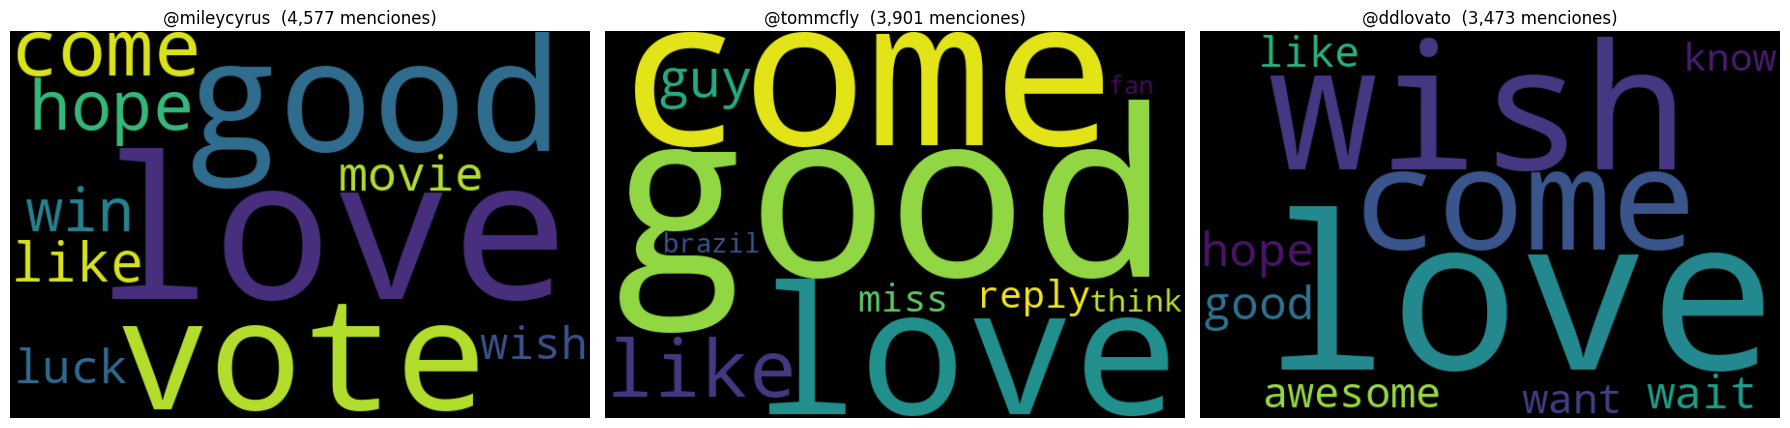

In [ ]:
fig, axes = plt.subplots(1, len(top_users), figsize=(6 * len(top_users), 5))
axes = [axes] if len(top_users) == 1 else axes

for ax, user in zip(axes, top_users):
    freqs = dict(top_words(resultados[user]["lemmas"]))
    wc = WordCloud(width=600, height=400, background_color="black",
                   max_words=TOP_WORDS, colormap="viridis",
                   prefer_horizontal=1.0).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"@{user}  ({mention_counts[user]:,} menciones)", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("wordclouds_top3.png", dpi=150, bbox_inches="tight")
plt.show()

### Evidencia
Se muestran tweets del corpus que contienen una palabra clave de cada usuario.

In [ ]:
def ejemplos(user, palabra, n=5):
    f = frames[user]
    return f[f["lemmas"].str.contains(rf"\b{palabra}\b")]["content"].head(n).tolist()

claves = {"mileycyrus": "vote", "tommcfly": "brazil", "ddlovato": "wait"}   # palabras clave de cada usuario

for user, palabra in claves.items():
    if user not in frames:
        continue
    print(f"\n=== @{user} — palabra clave: '{palabra}' ===")
    for tweet in ejemplos(user, palabra):
        print("-", tweet)


=== @mileycyrus — palabra clave: 'vote' ===
- @mileycyrus i dont think you can vote anymore! i tried 
- @mileycyrus voting is over. since like four days ago i think  i told all my friends 2 vote for you a million times. you will win! love you
- @MILEYCYRUS  WHAT ABOUT ME ??  I VOTE EVERY DAY FOR YOU !!!!!
- @mileycyrus I VOTED!!! do u have a personal myspace? i keep talking to fakes   i &lt;3 you. u helped me thru the hrdest time of my life! (: x
- @mileycyrus tell me where to vote and I will do so!!!! cause I'm from Germany I don't now where to do it..  btw: I love you and your music

=== @tommcfly — palabra clave: 'brazil' ===
- @tommcfly you know you love brazil more than anyone country  *I'm jealous* Love you
- @tommcfly  you canceled the concerts here in Brazil? it's because the rumors are saying that you canceled. And please, answer me. 
- @tommcfly I'm very happy that you're enjoing brazil, but feels bad that I coudn't buy my ticket to go to the rio's concert 
- @tommcfly Is it

## 8. Conclusiones

| Usuario | Menciones | Palabras dominantes (lemas) | Razón por la que se le cita |
|---|---|---|---|
| @mileycyrus | 4,577 | love, good, vote, come, hope, win, like, movie, luck, wish | Mensajes de apoyo y de buenos deseos. La presencia de `vote`, `win`, `movie` y `luck` (y `award`, `best` en los stems) sugiere que se le cita para pedir votos y desearle suerte en premios y en una película. |
| @tommcfly | 3,901 | good, come, love, like, guy, reply, miss, think, brazil, fan | Mensajes de fans que piden una respuesta (`reply`), expresan que lo extrañan (`miss`) y solicitan que visite Brasil (`come`, `brazil`). `guy` corresponde a `guys`, en alusión a la banda. |
| @ddlovato | 3,473 | love, wish, come, hope, good, wait, awesome, like, want, know | Expresiones de deseo y de expectativa (`wish`, `hope`, `wait`, `want`) sobre ver a la artista o esperar una novedad, junto con elogios (`awesome`, `love`). |


**Conclusión:** los tres usuarios son figuras públicas del entretenimiento y se les cita principalmente en mensajes de sus fans.

Las palabras `love`, `good`, `come` y `hope` se repiten en los tres corpus y reflejan el tono afectivo. Lo que diferencia a cada usuario son las palabras propias de cada uno: votaciones y premios en @mileycyrus, respuesta y gira en @tommcfly, y deseo y espera en @ddlovato.

**Observaciones metodológicas**

- La popularidad se define por número de menciones (`@usuario`) y no por cantidad de tweets publicados.
- El dataset contiene 1,600,000 registros.
- Cada corpus contiene un documento por tweet que menciona al usuario (4,560, 3,895 y 3,459 documentos). Es menor que el número de menciones porque un tweet puede mencionar más de una vez al mismo usuario.
- El contexto se limita a una ventana de 7 palabras a cada lado de la mención (`WINDOW = 7`).
- Además de las stopwords de spaCy, se excluyeron términos que no aportan a la interpretación: entidades HTML (`quot`, `amp`, `gt`, `lt`), interjecciones (`hey`, `hahaha`, `awww`) y los nombres propios `miley`, `tom` y `demi`, que encabezaban los conteos porque los fans se dirigen a los usuarios por su nombre.
- `Length` corresponde al número de caracteres del tweet original, incluidas las entidades HTML.
- Stemming reduce las palabras a su raíz (puede producir formas no léxicas); la lemmatización devuelve la forma canónica. Por legibilidad, el wordcloud utiliza lemas.
- Las razones indicadas son interpretaciones basadas en la frecuencia de palabras en el contexto de cada mención y en los tweets de ejemplo.